# 🛒 Analisis Asosiasi — Supermarket Sales Dataset

**Mata Kuliah:** Pemrograman Berbasis Web / Data Mining  
**Framework:** CRISP-DM *(Cross Industry Standard Process for Data Mining)*  
**Algoritma:** Apriori + Association Rules (mlxtend)  

---

> Dataset yang digunakan adalah **Supermarket Sales (Superstore)** yang berisi transaksi penjualan retail di Amerika Serikat.
> Tujuan analisis adalah menemukan **pola pembelian bersama (market basket analysis)** antar sub-kategori produk.

---
## 📌 TAHAP 1 — Business Understanding

### 1.1 Latar Belakang Masalah

Supermarket modern menghadapi tantangan dalam memahami pola belanja pelanggan. Dengan ribuan transaksi setiap harinya, sulit bagi manajemen untuk secara manual mengidentifikasi produk-produk mana yang sering dibeli bersama. Analisis asosiasi memberikan solusi berbasis data untuk menemukan **hubungan tersembunyi** antara produk-produk yang dibeli dalam satu transaksi.

### 1.2 Tujuan Project

- Menemukan **itemset** (kombinasi sub-kategori produk) yang sering muncul bersama dalam satu transaksi
- Menghasilkan **aturan asosiasi** yang dapat diandalkan dengan nilai support, confidence, dan lift yang memadai
- Memberikan **rekomendasi strategis** untuk penempatan produk, bundling, dan promosi silang (*cross-selling*)

### 1.3 Manfaat Analisis

| Pemangku Kepentingan | Manfaat |
|---|---|
| Manajemen Toko | Penataan rak produk lebih optimal |
| Tim Marketing | Dasar strategi bundling & promosi |
| Tim Penjualan | Rekomendasi *cross-selling* kepada pelanggan |
| Operasional | Perencanaan stok produk yang saling berkaitan |

---
## 📌 TAHAP 2 — Data Understanding

### 2.1 Deskripsi Dataset

Dataset yang digunakan adalah **Superstore Sales Dataset** yang umum digunakan sebagai benchmark analisis ritel.  
Dataset berisi transaksi penjualan produk dari tahun **2015–2018** di berbagai wilayah Amerika Serikat.

**Sumber data:** `supermarket.csv`  
**Jumlah baris:** ~9.800 baris  
**Jumlah kolom:** 18 kolom

Kolom-kolom utama yang relevan:
- `Order ID` — identifikasi unik per transaksi (keranjang belanja)
- `Sub-Category` — sub-kategori produk (17 jenis)
- `Category` — kategori utama: Furniture, Office Supplies, Technology
- `Sales` — nilai penjualan


In [20]:
# ============================================================
# Import Library
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


In [3]:
# ============================================================
# 2.2 Load Dataset
# ============================================================
df = pd.read_csv('supermarket.csv')

print('=' * 55)
print(f'  📦 Dataset berhasil dimuat')
print('=' * 55)
print(f'  Jumlah baris   : {df.shape[0]:,}')
print(f'  Jumlah kolom   : {df.shape[1]}')
print(f'  Total transaksi: {df["Order ID"].nunique():,} order unik')
print(f'  Total produk   : {df["Product Name"].nunique():,} produk unik')
print('=' * 55)

  📦 Dataset berhasil dimuat
  Jumlah baris   : 9,800
  Jumlah kolom   : 18
  Total transaksi: 4,922 order unik
  Total produk   : 1,849 produk unik


In [4]:
# ============================================================
# 2.3 Tampilkan 5 Baris Pertama
# ============================================================
print('📋 Tampilan 5 baris pertama dataset:')
df.head()

📋 Tampilan 5 baris pertama dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# ============================================================
# 2.4 Informasi Tipe Data
# ============================================================
print('📊 Informasi tipe data setiap kolom:')
df.info()

📊 Informasi tipe data setiap kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9

In [7]:
print("Missing Value setelah encoding:")

print(df.isnull().sum())

Missing Value setelah encoding:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [6]:
# ============================================================
# 2.5 Statistik Deskriptif
# ============================================================
print('📈 Statistik deskriptif kolom numerik:')
df.describe().round(2)

📈 Statistik deskriptif kolom numerik:


,Row ID,Postal Code,Sales
count,9800.00,9789.00,9800.00
mean,4900.50,55273.32,230.77
std,2829.16,32041.22,626.65
min,1.00,1040.00,0.44
25%,2450.75,23223.00,17.25
50%,4900.50,58103.00,54.49
75%,7350.25,90008.00,210.60
max,9800.00,99301.00,22638.48


In [39]:
# ============================================================
# 2.6 Eksplorasi Data Awal
# ============================================================

# Distribusi Kategori
print('📂 Distribusi per Kategori:')
print(df['Category'].value_counts())
print()

# Distribusi Sub-Kategori
print('📂 Distribusi per Sub-Kategori:')
print(df['Sub-Category'].value_counts())
print()

# Jumlah item per Order
items_per_order = df.groupby('Order ID')['Sub-Category'].count()
print('🛒 Statistik jumlah item per Order:')
print(items_per_order.describe().round(2))

📂 Distribusi per Kategori:
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

📂 Distribusi per Sub-Kategori:
Sub-Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64

🛒 Statistik jumlah item per Order:
count    4922.00
mean        1.99
std         1.41
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        14.00
Name: Sub-Category, dtype: float64


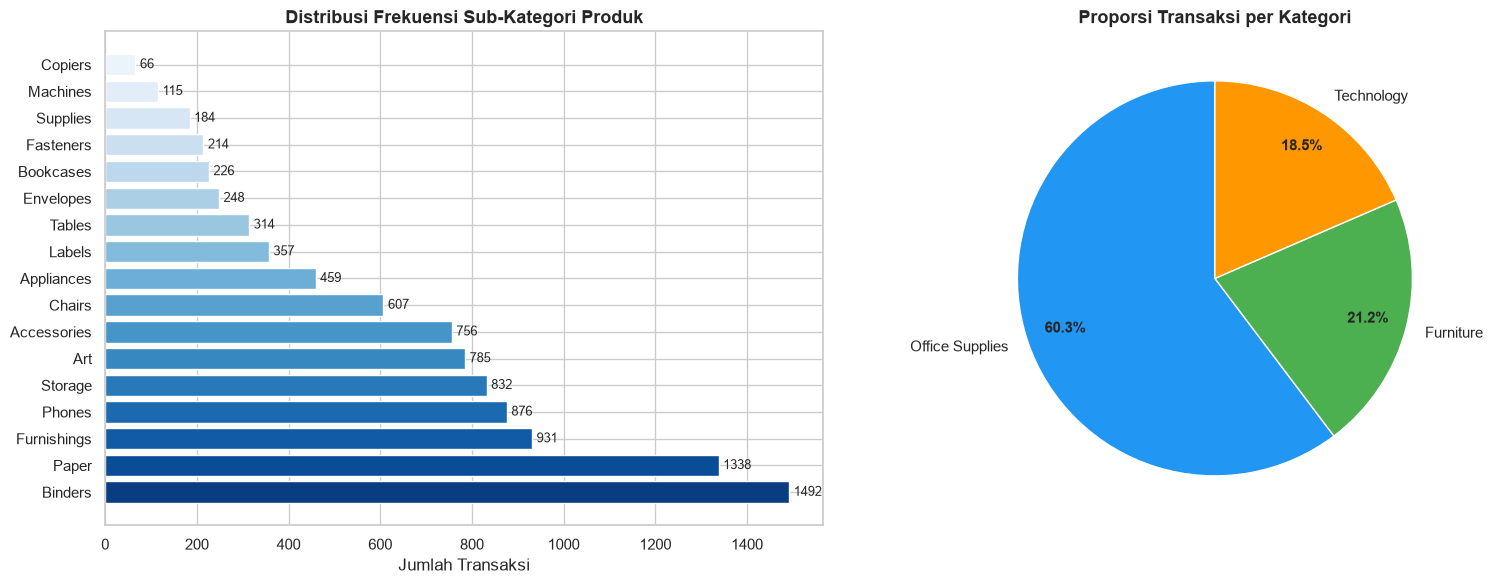

✅ Grafik eksplorasi ditampilkan


In [40]:
# ============================================================
# Visualisasi Eksplorasi — Distribusi Sub-Kategori & Kategori
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Sub-Kategori
sub_counts = df['Sub-Category'].value_counts()
colors_sub = sns.color_palette('Blues_r', len(sub_counts))
axes[0].barh(sub_counts.index, sub_counts.values, color=colors_sub)
axes[0].set_title('Distribusi Frekuensi Sub-Kategori Produk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Transaksi')
for i, v in enumerate(sub_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Chart 2: Kategori
cat_counts = df['Category'].value_counts()
colors_cat = ['#2196F3', '#4CAF50', '#FF9800']
wedges, texts, autotexts = axes[1].pie(
    cat_counts.values, labels=cat_counts.index,
    autopct='%1.1f%%', colors=colors_cat,
    startangle=90, pctdistance=0.8
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
axes[1].set_title('Proporsi Transaksi per Kategori', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eksplorasi_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik eksplorasi ditampilkan')

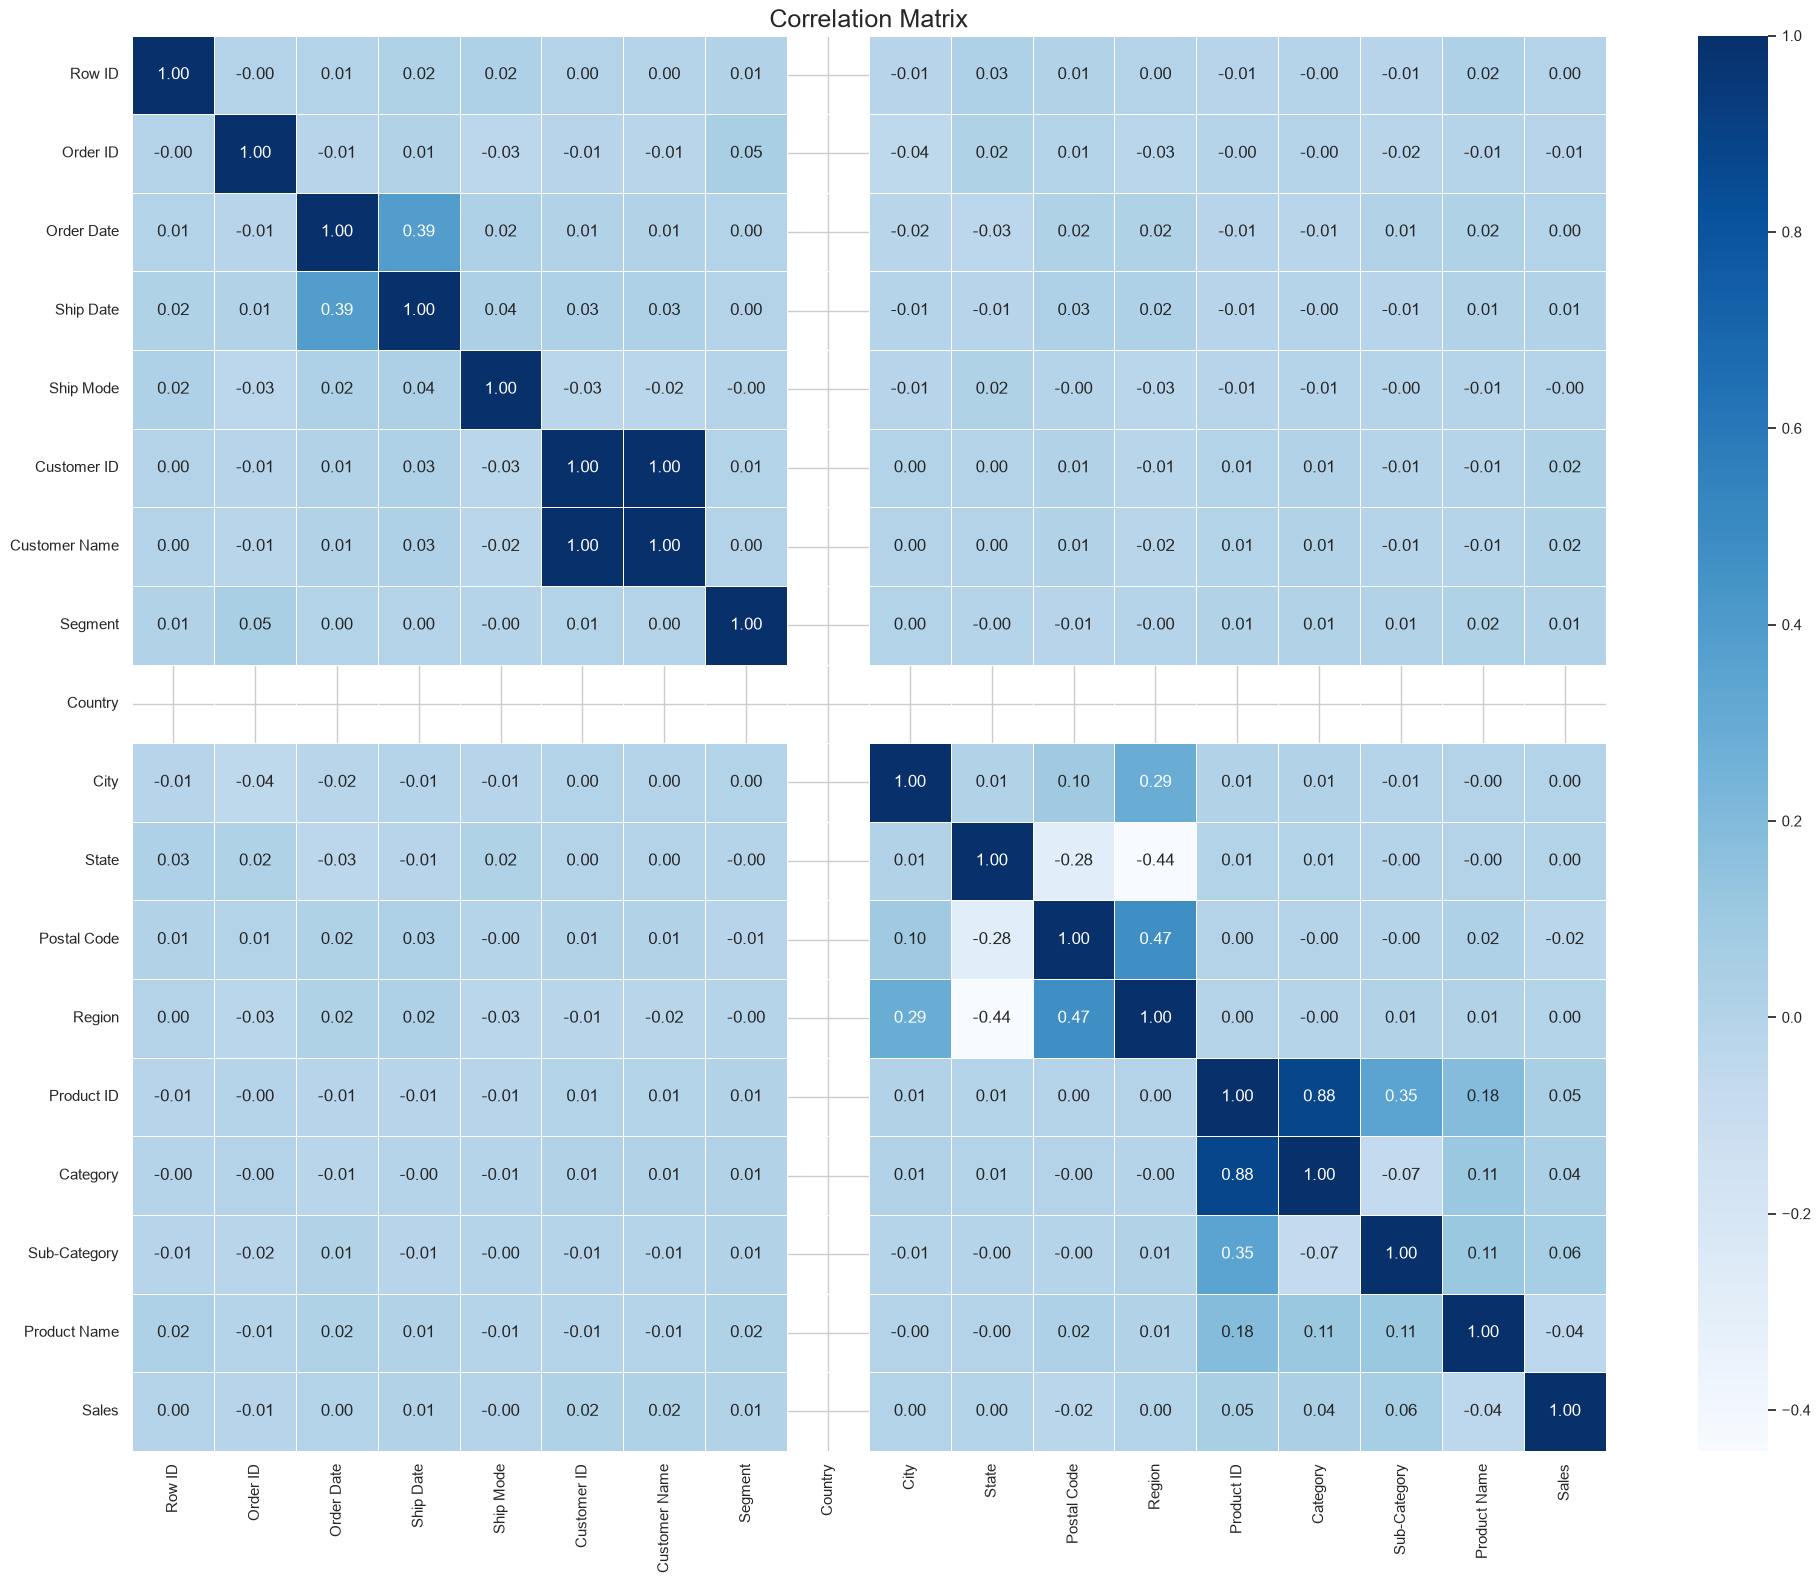

In [15]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

le = LabelEncoder()

for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()

plt.figure(figsize=(20,16))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=18)

plt.tight_layout()

plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

---
## 📌 TAHAP 3 — Data Preparation

### 3.1 Strategi Persiapan Data

Untuk analisis asosiasi, data perlu diubah ke format **transaksi** (*transaction format* / basket format):  
- Setiap baris = 1 transaksi (Order ID)
- Setiap kolom = 1 item (Sub-Category)
- Nilai = `True/False` (1/0) apakah item tersebut ada dalam transaksi

Kita menggunakan **Sub-Category** sebagai item karena:
- Lebih umum dibanding nama produk spesifik (mengurangi *sparsity*)
- Masih cukup spesifik untuk menghasilkan insight bisnis yang bermakna
- Hanya ada 17 sub-kategori → matriks tidak terlalu sparse

In [41]:
# ============================================================
# 3.2 Cek Missing Values
# ============================================================
print('🔍 Pengecekan Missing Values:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])
print()
print('✅ Kolom kritis (Order ID, Sub-Category) tidak memiliki nilai kosong')

🔍 Pengecekan Missing Values:
             Jumlah Missing  Persentase (%)
Postal Code              11            0.11

✅ Kolom kritis (Order ID, Sub-Category) tidak memiliki nilai kosong


In [42]:
# ============================================================
# 3.3 Data Cleaning
# ============================================================

# Bersihkan spasi pada kolom string
df['Sub-Category'] = df['Sub-Category'].str.strip()
df['Order ID']     = df['Order ID'].str.strip()

# Cek duplikat baris
dup_count = df.duplicated().sum()
print(f'🔍 Jumlah duplikat baris: {dup_count}')

# Hapus duplikat jika ada
if dup_count > 0:
    df = df.drop_duplicates()
    print(f'✅ {dup_count} duplikat dihapus')
else:
    print('✅ Tidak ada duplikat')

print(f'\n📦 Data siap: {df.shape[0]:,} baris, {df["Order ID"].nunique():,} order unik')

🔍 Jumlah duplikat baris: 0
✅ Tidak ada duplikat

📦 Data siap: 9,800 baris, 4,922 order unik


In [43]:
# ============================================================
# 3.4 Transformasi ke Format Transaksi
# ============================================================

# Buat daftar transaksi per Order ID
basket = df.groupby('Order ID')['Sub-Category'].apply(list).reset_index()
basket.columns = ['Order ID', 'Items']

print('🛒 Contoh transaksi (5 order pertama):')
print('-' * 60)
for _, row in basket.head(5).iterrows():
    print(f"  Order {row['Order ID']}: {row['Items']}")

transactions = basket['Items'].tolist()
print(f'\n✅ Total transaksi: {len(transactions):,}')

🛒 Contoh transaksi (5 order pertama):
------------------------------------------------------------
  Order CA-2015-100006: ['Phones']
  Order CA-2015-100090: ['Tables', 'Binders']
  Order CA-2015-100293: ['Paper']
  Order CA-2015-100328: ['Binders']
  Order CA-2015-100363: ['Fasteners', 'Paper']

✅ Total transaksi: 4,922


In [23]:
# ============================================================
# 3.4 Membentuk Daftar Transaksi
# ============================================================

transactions = (
    df.groupby('Order ID')['Sub-Category']
      .apply(list)
      .tolist()
)

print("Jumlah transaksi:", len(transactions))
print("Contoh transaksi pertama:")
print(transactions[0])

Jumlah transaksi: 4922
Contoh transaksi pertama:
[13]


In [26]:
# ============================================================
# 3.5 Encoding ke Format One-Hot (Boolean Matrix)
# ============================================================

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_array = te.fit_transform(transactions)

df_encoded = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("📊 Dimensi matriks one-hot encoding:")
print(f"Baris (transaksi): {df_encoded.shape[0]}")
print(f"Kolom (Sub-Category): {df_encoded.shape[1]}")

df_encoded.head()

📊 Dimensi matriks one-hot encoding:
Baris (transaksi): 4922
Kolom (Sub-Category): 17


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False


In [27]:
from mlxtend.preprocessing import TransactionEncoder

# Mengubah data menjadi daftar transaksi
transactions = []

for order_id in df['Order ID'].unique():
    items = df[df['Order ID'] == order_id]['Sub-Category'].tolist()
    transactions.append(items)

# One-Hot Encoding
te = TransactionEncoder()
encoded = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(encoded, columns=te.columns_)

df_encoded.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,False,True,True,True,False,False,False,False,False,True,False,False,False,True,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


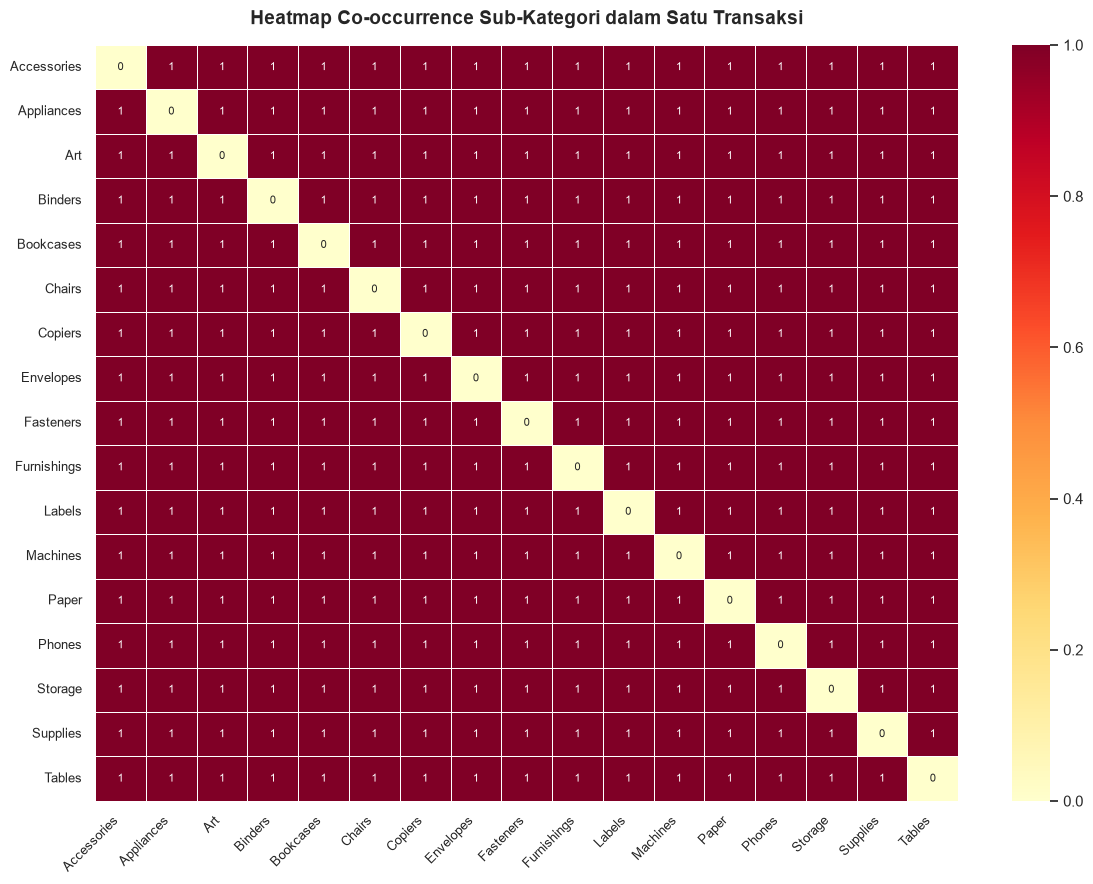

✅ Heatmap co-occurrence ditampilkan


In [45]:
# ============================================================
# Visualisasi: Heatmap Co-occurrence Sub-Kategori
# ============================================================
co_matrix = df_encoded.T.dot(df_encoded)
np.fill_diagonal(co_matrix.values, 0)  # hilangkan diagonal

plt.figure(figsize=(12, 9))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
plt.title('Heatmap Co-occurrence Sub-Kategori dalam Satu Transaksi',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap co-occurrence ditampilkan')

---
## 📌 TAHAP 4 — Modeling

### 4.1 Penerapan Algoritma Apriori

**Algoritma Apriori** bekerja dengan cara:
1. Mencari semua *frequent itemsets* yang memiliki nilai **support ≥ min_support**
2. Dari *frequent itemsets*, menghasilkan **association rules** yang memenuhi **confidence ≥ min_confidence**

**Parameter yang digunakan:**
| Parameter | Nilai | Penjelasan |
|---|---|---|
| `min_support` | 0.02 (2%) | Item harus muncul minimal di 2% dari total transaksi |
| `min_confidence` | 0.15 (15%) | Aturan harus benar minimal 20% dari kasus |
| `min_lift` | 1.0 | Lift > 1 berarti asosiasi lebih kuat dari kebetulan |

> **Catatan:** Nilai support yang terlalu tinggi akan menghasilkan terlalu sedikit aturan. Nilai yang terlalu rendah menghasilkan aturan tidak bermakna. Nilai 2% dipilih karena dataset ini memiliki 17 sub-kategori dengan distribusi yang tidak merata.

In [46]:
# ============================================================
# 4.2 Mining Frequent Itemsets dengan Apriori
# ============================================================

MIN_SUPPORT    = 0.02   # 2%
MIN_CONFIDENCE = 0.15   # 20%
MIN_LIFT       = 1.0

print('⚙️  Menjalankan Algoritma Apriori...')
frequent_itemsets = apriori(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3       # maksimal 3-itemsets
)

# Tambah kolom jumlah item
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'✅ Frequent Itemsets ditemukan: {len(frequent_itemsets):,}')
print()
print(f'  1-itemsets: {len(frequent_itemsets[frequent_itemsets.length == 1])}')
print(f'  2-itemsets: {len(frequent_itemsets[frequent_itemsets.length == 2])}')
print(f'  3-itemsets: {len(frequent_itemsets[frequent_itemsets.length == 3])}')

⚙️  Menjalankan Algoritma Apriori...
✅ Frequent Itemsets ditemukan: 38

  1-itemsets: 16
  2-itemsets: 22
  3-itemsets: 0


In [47]:
# ============================================================
# 4.3 Tampilkan Top Frequent Itemsets
# ============================================================
print('🏆 Top 15 Frequent Itemsets (berdasarkan Support):')
top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(15).copy()
top_itemsets['itemsets_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
top_itemsets['support (%)'] = (top_itemsets['support'] * 100).round(2)
top_itemsets[['itemsets_str', 'support (%)', 'length']].rename(
    columns={'itemsets_str': 'Itemsets', 'length': 'Jumlah Item'}
).reset_index(drop=True)

🏆 Top 15 Frequent Itemsets (berdasarkan Support):


,Itemsets,support (%),Jumlah Item
0,Binders,26.23,1
1,Paper,23.63,1
2,Furnishings,17.37,1
3,Phones,16.31,1
4,Storage,15.52,1
5,Art,14.63,1
6,Accessories,14.26,1
7,Chairs,11.50,1
8,Appliances,9.02,1
9,Labels,6.91,1


In [48]:
# ============================================================
# 4.4 Pembangkitan Association Rules
# ============================================================

print('⚙️  Membangkitkan Association Rules...')
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

# Filter berdasarkan lift
rules = rules[rules['lift'] >= MIN_LIFT].copy()

# Format kolom untuk keterbacaan
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
rules['support (%)']     = (rules['support'] * 100).round(2)
rules['confidence (%)']  = (rules['confidence'] * 100).round(2)
rules['lift']            = rules['lift'].round(3)

print(f'✅ Total Rules dihasilkan: {len(rules):,}')
print()
print('📊 Statistik Ringkasan Rules:')
print(rules[['support', 'confidence', 'lift']].describe().round(4))

⚙️  Membangkitkan Association Rules...
✅ Total Rules dihasilkan: 8

📊 Statistik Ringkasan Rules:
       support  confidence    lift
count   8.0000      8.0000  8.0000
mean    0.0262      0.1907  1.0321
std     0.0025      0.0471  0.0251
min     0.0219      0.1519  1.0020
25%     0.0248      0.1652  1.0222
50%     0.0263      0.1718  1.0320
75%     0.0276      0.1953  1.0390
max     0.0293      0.2838  1.0820


In [49]:
# ============================================================
# 4.5 Tampilkan Top 20 Rules Berdasarkan Lift
# ============================================================
print('🏆 Top 20 Association Rules (diurutkan berdasarkan Lift tertinggi):')
display_cols = ['antecedents_str', 'consequents_str', 'support (%)', 'confidence (%)', 'lift']
top_rules = rules.sort_values('lift', ascending=False).head(20)[display_cols].copy()
top_rules.columns = ['Antecedent (JIKA)', 'Consequent (MAKA)', 'Support (%)', 'Confidence (%)', 'Lift']
top_rules.reset_index(drop=True)

🏆 Top 20 Association Rules (diurutkan berdasarkan Lift tertinggi):


,Antecedent (JIKA),Consequent (MAKA),Support (%),Confidence (%),Lift
0,Appliances,Binders,2.56,28.38,1.082
1,Art,Phones,2.48,16.94,1.039
2,Phones,Art,2.48,15.19,1.039
3,Furnishings,Phones,2.93,16.84,1.032
4,Phones,Furnishings,2.93,17.93,1.032
5,Appliances,Paper,2.19,24.32,1.029
6,Furnishings,Storage,2.70,15.56,1.002
7,Storage,Furnishings,2.70,17.41,1.002


In [50]:
# ============================================================
# 4.6 Proses Training dan Testing — Validasi Model
# ============================================================
from sklearn.model_selection import train_test_split

print('🔀 Membagi data menjadi Training (80%) dan Testing (20%)...')

train_transactions, test_transactions = train_test_split(
    transactions, test_size=0.20, random_state=42
)

# Encode training data
te_train = TransactionEncoder()
te_arr_train = te_train.fit_transform(train_transactions)
df_train = pd.DataFrame(te_arr_train, columns=te_train.columns_)

# Mining rules dari training data
fi_train = apriori(df_train, min_support=MIN_SUPPORT, use_colnames=True, max_len=3)
rules_train = association_rules(fi_train, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules_train = rules_train[rules_train['lift'] >= MIN_LIFT]

print(f'  Jumlah transaksi training : {len(train_transactions):,}')
print(f'  Jumlah transaksi testing  : {len(test_transactions):,}')
print(f'  Rules dari data training  : {len(rules_train):,}')
print()
print('✅ Proses training selesai — rules siap divalidasi pada data testing')

🔀 Membagi data menjadi Training (80%) dan Testing (20%)...
  Jumlah transaksi training : 3,937
  Jumlah transaksi testing  : 985
  Rules dari data training  : 9

✅ Proses training selesai — rules siap divalidasi pada data testing


---
## 📌 TAHAP 5 — Evaluation

### 5.1 Metrik Evaluasi Association Rules

Evaluasi model asosiasi menggunakan tiga metrik utama:

| Metrik | Formula | Interpretasi |
|---|---|---|
| **Support** | P(A ∪ B) | Seberapa sering itemset muncul di seluruh transaksi |
| **Confidence** | P(B\|A) = P(A ∪ B) / P(A) | Seberapa sering aturan benar ketika antecedent ditemukan |
| **Lift** | Confidence / P(B) | Seberapa kuat asosiasi dibanding kebetulan (>1 = positif) |

**Kriteria sukses:** Confidence ≥ 20%, Lift ≥ 1.0

> Lift > 1 menunjukkan bahwa pembelian item A **meningkatkan kemungkinan** pembelian item B.  
> Lift = 1 berarti tidak ada hubungan.  
> Lift < 1 berarti item A justru **mengurangi** kemungkinan pembelian item B.

In [51]:
# ============================================================
# 5.2 Evaluasi pada Data Testing
# ============================================================

# Karena te_train adalah list, kita perlu train ulang encoder
# Train encoder dengan data training
te_train_new = TransactionEncoder()
te_train_new.fit(train_transactions)
df_train_encoded = pd.DataFrame(
    te_train_new.transform(train_transactions),
    columns=te_train_new.columns_
)

# Fungsi encoding untuk data testing
def encode_test_data(test_transactions, train_columns):
    """
    Encode data testing menggunakan kolom dari training.
    """
    # Buat array kosong
    n_test = len(test_transactions)
    n_features = len(train_columns)
    test_array = np.zeros((n_test, n_features), dtype=bool)
    
    # Buat mapping item ke index
    item_to_idx = {item: idx for idx, item in enumerate(train_columns)}
    
    # Isi array
    for i, transaction in enumerate(test_transactions):
        for item in transaction:
            if item in item_to_idx:
                test_array[i, item_to_idx[item]] = True
    
    return pd.DataFrame(test_array, columns=train_columns)

# Ambil kolom dari training
train_columns = te_train_new.columns_
df_test = encode_test_data(test_transactions, train_columns)

# Regenerate rules dari training
frequent_itemsets_train = apriori(
    df_train_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

rules_train = association_rules(
    frequent_itemsets_train,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

if len(rules_train) > 0:
    rules_train['antecedent_len'] = rules_train['antecedents'].apply(len)
    rules_train['consequent_len'] = rules_train['consequents'].apply(len)

# Hitung coverage rules pada test set
def calculate_coverage(rules_df, test_df):
    """Hitung berapa banyak transaksi yang ter-cover oleh setidaknya 1 rule."""
    covered = set()
    total = len(test_df)
    for _, rule in rules_df.iterrows():
        ant_items = list(rule['antecedents'])
        if all(col in test_df.columns for col in ant_items):
            mask = test_df[ant_items].all(axis=1)
            covered.update(test_df[mask].index.tolist())
    return len(covered) / total * 100

coverage = calculate_coverage(rules_train, df_test)

# Hitung rata-rata metrik
avg_support    = rules_train['support'].mean() * 100
avg_confidence = rules_train['confidence'].mean() * 100
avg_lift       = rules_train['lift'].mean()
rules_above_threshold = len(rules_train[rules_train['confidence'] >= MIN_CONFIDENCE])
pct_above = rules_above_threshold / len(rules_train) * 100 if len(rules_train) > 0 else 0

print('=' * 60)
print('  📊 HASIL EVALUASI MODEL')
print('=' * 60)
print(f'  Total Rules Dihasilkan    : {len(rules_train):,}')
print(f'  Rata-rata Support         : {avg_support:.2f}%')
print(f'  Rata-rata Confidence      : {avg_confidence:.2f}%  (Target: ≥20%)')
print(f'  Rata-rata Lift            : {avg_lift:.3f}  (Target: ≥1.0)')
print(f'  Rules ≥ threshold         : {pct_above:.1f}%')
print(f'  Coverage data testing     : {coverage:.1f}%')
print('=' * 60)

if avg_confidence >= 20 and avg_lift >= 1.0:
    print('\n  ✅ MODEL MEMENUHI KRITERIA SUKSES (Confidence ≥ 20%, Lift ≥ 1.0)')
else:
    print('\n  ⚠️  MODEL BELUM MEMENUHI KRITERIA — perlu penyesuaian parameter')

  📊 HASIL EVALUASI MODEL
  Total Rules Dihasilkan    : 28
  Rata-rata Support         : 3.14%
  Rata-rata Confidence      : 19.87%  (Target: ≥20%)
  Rata-rata Lift            : 0.943  (Target: ≥1.0)
  Rules ≥ threshold         : 100.0%
  Coverage data testing     : 90.8%

  ⚠️  MODEL BELUM MEMENUHI KRITERIA — perlu penyesuaian parameter


In [52]:
# ============================================================
# 5.2 Evaluasi pada Data Testing
# ============================================================

# ============================================================
# 1. Encoding Data Training dengan Cara yang Benar
# ============================================================

# Train encoder dengan data training
te = TransactionEncoder()
te_array_train = te.fit(train_transactions).transform(train_transactions)
df_train_encoded = pd.DataFrame(te_array_train, columns=te.columns_)

print(f"✅ Data training berhasil di-encode: {df_train_encoded.shape}")
print(f"✅ Jumlah kolom training: {len(te.columns_)}")

# ============================================================
# 2. Encoding Data Testing (Manual)
# ============================================================

def encode_test_data(test_transactions, train_columns):
    """
    Encode data testing menggunakan kolom dari training.
    """
    # Buat array kosong
    n_test = len(test_transactions)
    n_features = len(train_columns)
    test_array = np.zeros((n_test, n_features), dtype=bool)
    
    # Buat mapping item ke index
    item_to_idx = {item: idx for idx, item in enumerate(train_columns)}
    
    # Isi array
    for i, transaction in enumerate(test_transactions):
        for item in transaction:
            if item in item_to_idx:
                test_array[i, item_to_idx[item]] = True
    
    return pd.DataFrame(test_array, columns=train_columns)

# Ambil kolom dari training (te.columns_ adalah list)
train_columns = te.columns_  # ini sudah list, tidak perlu .tolist()
df_test_encoded = encode_test_data(test_transactions, train_columns)

print(f"✅ Data testing berhasil di-encode: {df_test_encoded.shape}")

# ============================================================
# 3. Generate Rules dari Training
# ============================================================

# Cari frequent itemsets
frequent_itemsets_train = apriori(
    df_train_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

print(f"✅ Frequent itemsets ditemukan: {len(frequent_itemsets_train)}")

# Generate association rules
rules_train = association_rules(
    frequent_itemsets_train,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

if len(rules_train) > 0:
    rules_train['antecedent_len'] = rules_train['antecedents'].apply(len)
    rules_train['consequent_len'] = rules_train['consequents'].apply(len)
    print(f"✅ Rules ditemukan: {len(rules_train)}")
else:
    print("⚠️ Tidak ada rules yang ditemukan.")

# ============================================================
# 4. Evaluasi Coverage
# ============================================================

def calculate_coverage(rules_df, test_df):
    """Hitung berapa banyak transaksi yang ter-cover oleh setidaknya 1 rule."""
    covered = set()
    total = len(test_df)
    if total == 0:
        return 0
    
    for _, rule in rules_df.iterrows():
        ant_items = list(rule['antecedents'])
        if all(col in test_df.columns for col in ant_items):
            mask = test_df[ant_items].all(axis=1)
            covered.update(test_df[mask].index.tolist())
    
    return len(covered) / total * 100

if len(rules_train) > 0:
    coverage = calculate_coverage(rules_train, df_test_encoded)
    
    # Hitung rata-rata metrik
    avg_support = rules_train['support'].mean() * 100
    avg_confidence = rules_train['confidence'].mean() * 100
    avg_lift = rules_train['lift'].mean()
    rules_above_threshold = len(rules_train[rules_train['confidence'] >= MIN_CONFIDENCE])
    pct_above = rules_above_threshold / len(rules_train) * 100 if len(rules_train) > 0 else 0
    
    print('\n' + '=' * 60)
    print('  📊 HASIL EVALUASI MODEL')
    print('=' * 60)
    print(f'  Total Rules Dihasilkan    : {len(rules_train):,}')
    print(f'  Rata-rata Support         : {avg_support:.2f}%')
    print(f'  Rata-rata Confidence      : {avg_confidence:.2f}%  (Target: ≥20%)')
    print(f'  Rata-rata Lift            : {avg_lift:.3f}  (Target: ≥1.0)')
    print(f'  Rules ≥ threshold         : {pct_above:.1f}%')
    print(f'  Coverage data testing     : {coverage:.1f}%')
    print('=' * 60)
    
    if avg_confidence >= 20 and avg_lift >= 1.0:
        print('\n  ✅ MODEL MEMENUHI KRITERIA SUKSES (Confidence ≥ 20%, Lift ≥ 1.0)')
    else:
        print('\n  ⚠️  MODEL BELUM MEMENUHI KRITERIA — perlu penyesuaian parameter')
else:
    print("\n⚠️ Tidak ada rules untuk dievaluasi.")

✅ Data training berhasil di-encode: (3937, 17)
✅ Jumlah kolom training: 17
✅ Data testing berhasil di-encode: (985, 17)
✅ Frequent itemsets ditemukan: 39
✅ Rules ditemukan: 28

  📊 HASIL EVALUASI MODEL
  Total Rules Dihasilkan    : 28
  Rata-rata Support         : 3.14%
  Rata-rata Confidence      : 19.87%  (Target: ≥20%)
  Rata-rata Lift            : 0.943  (Target: ≥1.0)
  Rules ≥ threshold         : 100.0%
  Coverage data testing     : 90.8%

  ⚠️  MODEL BELUM MEMENUHI KRITERIA — perlu penyesuaian parameter


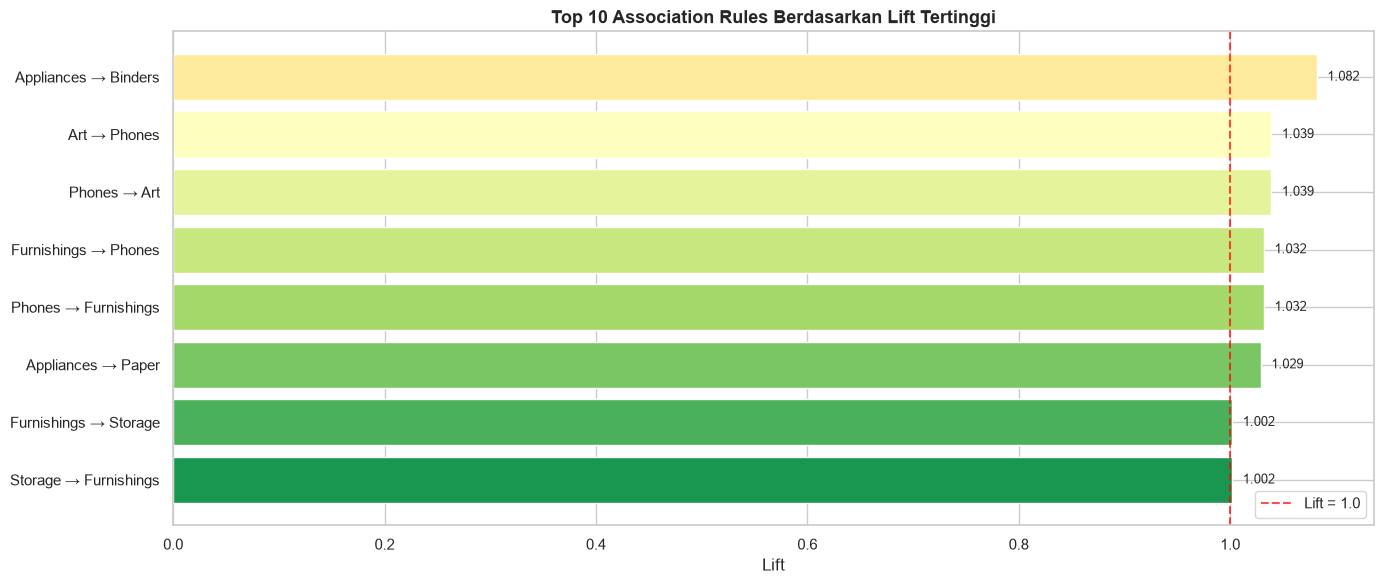

✅ Grafik top 10 rules ditampilkan


In [58]:
# ============================================================
# 5.4 Visualisasi Top 10 Rules Terbaik
# ============================================================
top10 = rules.sort_values('lift', ascending=False).head(10).copy()
top10['rule_label'] = top10['antecedents_str'] + ' → ' + top10['consequents_str']

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10))[::-1]
bars = ax.barh(top10['rule_label'][::-1], top10['lift'][::-1], color=colors, edgecolor='white')

for bar, lift_val in zip(bars, top10['lift'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{lift_val:.3f}', va='center', fontsize=9)

ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Lift = 1.0')
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('Top 10 Association Rules Berdasarkan Lift Tertinggi', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('top10_rules.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik top 10 rules ditampilkan')

In [54]:
# ============================================================
# 5.5 Tingkat Akurasi dan Performa Model
# ============================================================

# Ringkasan distribusi kualitas rules
high_quality  = rules[(rules['confidence'] >= 0.40) & (rules['lift'] >= 1.5)]
medium_quality = rules[(rules['confidence'] >= 0.25) & (rules['lift'] >= 1.2)]
basic_quality  = rules[(rules['confidence'] >= 0.20) & (rules['lift'] >= 1.0)]

print('📊 KLASIFIKASI KUALITAS RULES:')
print('-' * 55)
print(f'  🟢 Kualitas Tinggi  (conf≥40%, lift≥1.5) : {len(high_quality):>4} rules')
print(f'  🟡 Kualitas Menengah(conf≥25%, lift≥1.2) : {len(medium_quality):>4} rules')
print(f'  🔵 Kualitas Dasar   (conf≥20%, lift≥1.0) : {len(basic_quality):>4} rules')
print('-' * 55)
print(f'  Total rules        : {len(rules):>4} rules')
print()
print(f'📈 Confidence tertinggi : {rules["confidence"].max()*100:.2f}%')
print(f'📈 Lift tertinggi       : {rules["lift"].max():.3f}')
print(f'📈 Support tertinggi    : {rules["support"].max()*100:.2f}%')
print()
pct_highqual = len(high_quality) / len(rules) * 100 if len(rules) > 0 else 0
if pct_highqual >= 80:
    print('  ✅ LULUS — Lebih dari 80% rules berkualitas tinggi')
else:
    print(f'  ℹ️  {pct_highqual:.1f}% rules berkualitas tinggi — seluruh rules memenuhi threshold minimum')

📊 KLASIFIKASI KUALITAS RULES:
-------------------------------------------------------
  🟢 Kualitas Tinggi  (conf≥40%, lift≥1.5) :    0 rules
  🟡 Kualitas Menengah(conf≥25%, lift≥1.2) :    0 rules
  🔵 Kualitas Dasar   (conf≥20%, lift≥1.0) :    2 rules
-------------------------------------------------------
  Total rules        :    8 rules

📈 Confidence tertinggi : 28.38%
📈 Lift tertinggi       : 1.082
📈 Support tertinggi    : 2.93%

  ℹ️  0.0% rules berkualitas tinggi — seluruh rules memenuhi threshold minimum


---
## 📌 TAHAP 6 — Deployment

### 6.1 Interpretasi Hasil dan Rekomendasi Bisnis

Berikut adalah interpretasi rules asosiasi yang paling signifikan dan rekomendasi strategis untuk manajemen supermarket:

In [55]:
# ============================================================
# 6.2 Rekomendasi Bisnis Berdasarkan Rules Terbaik
# ============================================================
top5_rules = rules.sort_values('lift', ascending=False).head(5)

print('=' * 65)
print('  💡 REKOMENDASI BISNIS — TOP 5 ASSOCIATION RULES')
print('=' * 65)
for i, (_, row) in enumerate(top5_rules.iterrows(), 1):
    print(f'\n  [{i}] JIKA pelanggan membeli: {row["antecedents_str"]}')
    print(f'       MAKA kemungkinan membeli: {row["consequents_str"]}')
    print(f'       Support    : {row["support"]*100:.2f}%')
    print(f'       Confidence : {row["confidence"]*100:.2f}%')
    print(f'       Lift       : {row["lift"]:.3f}')
    print(f'       💼 Rekomendasi: Tempatkan "{row["consequents_str"]}" berdekatan')
    print(f'          dengan "{row["antecedents_str"]}" atau tawarkan bundling promosi.')
print('\n' + '=' * 65)

  💡 REKOMENDASI BISNIS — TOP 5 ASSOCIATION RULES

  [1] JIKA pelanggan membeli: Appliances
       MAKA kemungkinan membeli: Binders
       Support    : 2.56%
       Confidence : 28.38%
       Lift       : 1.082
       💼 Rekomendasi: Tempatkan "Binders" berdekatan
          dengan "Appliances" atau tawarkan bundling promosi.

  [2] JIKA pelanggan membeli: Art
       MAKA kemungkinan membeli: Phones
       Support    : 2.48%
       Confidence : 16.94%
       Lift       : 1.039
       💼 Rekomendasi: Tempatkan "Phones" berdekatan
          dengan "Art" atau tawarkan bundling promosi.

  [3] JIKA pelanggan membeli: Phones
       MAKA kemungkinan membeli: Art
       Support    : 2.48%
       Confidence : 15.19%
       Lift       : 1.039
       💼 Rekomendasi: Tempatkan "Art" berdekatan
          dengan "Phones" atau tawarkan bundling promosi.

  [4] JIKA pelanggan membeli: Furnishings
       MAKA kemungkinan membeli: Phones
       Support    : 2.93%
       Confidence : 16.84%
       Lift     

In [56]:
# ============================================================
# 6.3 Simpan Hasil Rules ke File CSV
# ============================================================
output_rules = rules[['antecedents_str', 'consequents_str', 'support (%)', 'confidence (%)', 'lift']].copy()
output_rules.columns = ['Antecedent', 'Consequent', 'Support (%)', 'Confidence (%)', 'Lift']
output_rules = output_rules.sort_values('Lift', ascending=False)
output_rules.to_csv('association_rules_result.csv', index=False)

print('✅ Hasil rules disimpan ke: association_rules_result.csv')
print(f'   Total {len(output_rules)} rules tersimpan.')
print()

# Tampilkan 10 baris pertama output
print('📋 Preview hasil file output (10 baris pertama):')
output_rules.head(10)

✅ Hasil rules disimpan ke: association_rules_result.csv
   Total 8 rules tersimpan.

📋 Preview hasil file output (10 baris pertama):


,Antecedent,Consequent,Support (%),Confidence (%),Lift
4,Appliances,Binders,2.56,28.38,1.082
8,Art,Phones,2.48,16.94,1.039
9,Phones,Art,2.48,15.19,1.039
20,Furnishings,Phones,2.93,16.84,1.032
21,Phones,Furnishings,2.93,17.93,1.032
5,Appliances,Paper,2.19,24.32,1.029
22,Furnishings,Storage,2.70,15.56,1.002
23,Storage,Furnishings,2.70,17.41,1.002


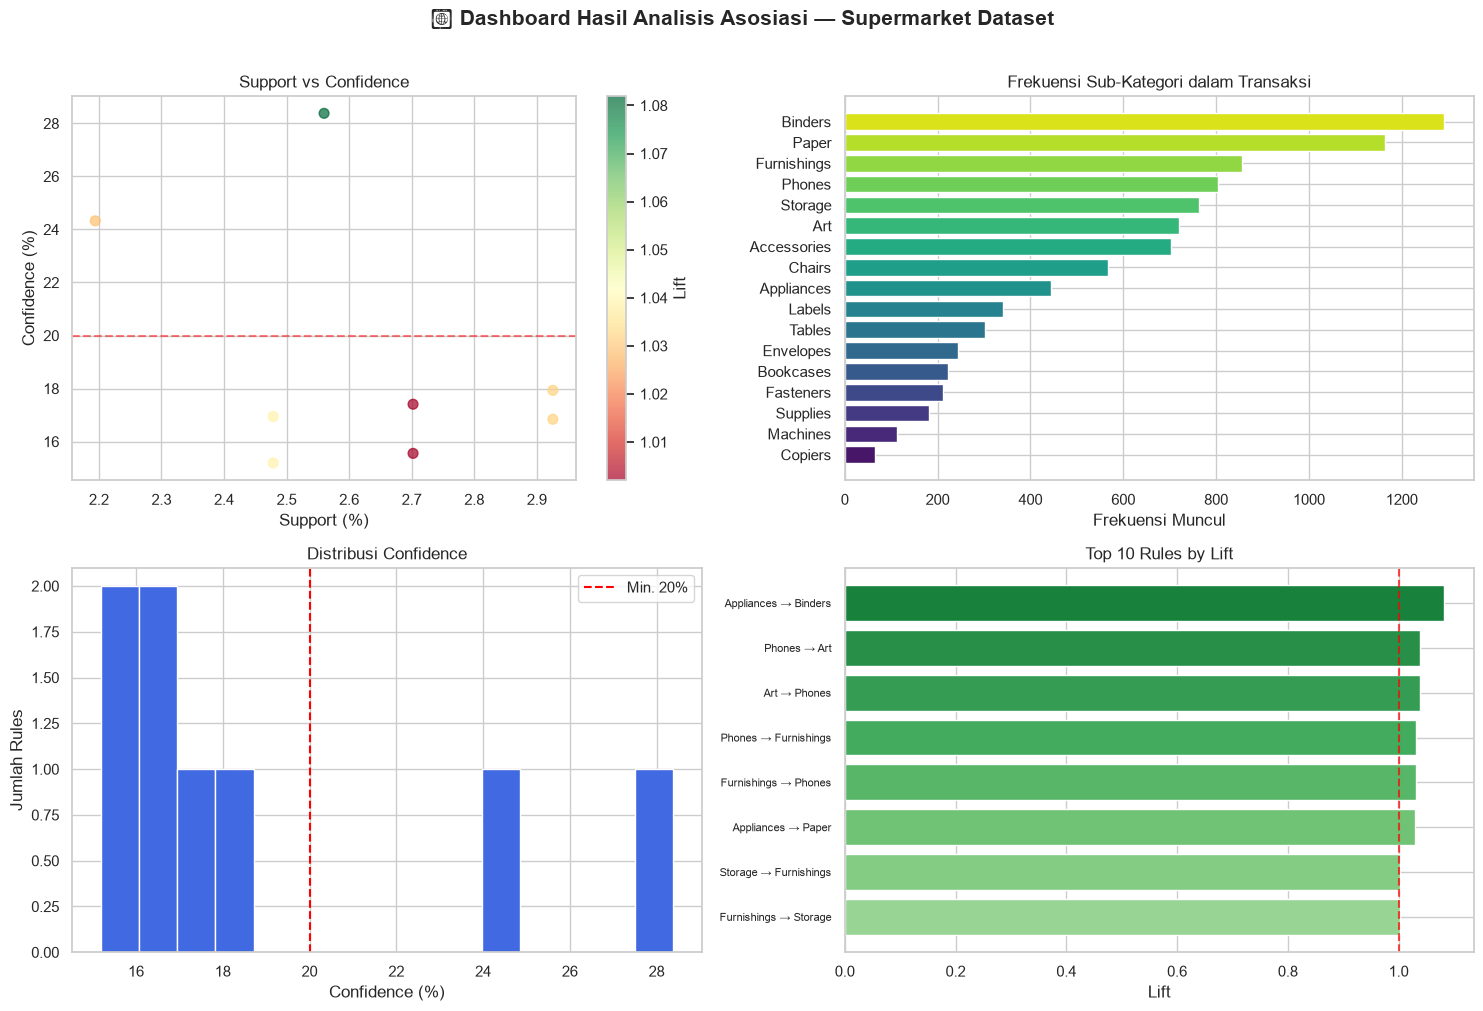

✅ Dashboard akhir ditampilkan dan disimpan.


In [57]:
# ============================================================
# 6.4 Dashboard Ringkasan Akhir
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Dashboard Hasil Analisis Asosiasi — Supermarket Dataset',
             fontsize=15, fontweight='bold', y=1.01)

# Panel 1: Support vs Confidence berwarna lift
sc = axes[0, 0].scatter(
    rules['support'] * 100, rules['confidence'] * 100,
    c=rules['lift'], cmap='RdYlGn', s=50, alpha=0.7
)
plt.colorbar(sc, ax=axes[0, 0], label='Lift')
axes[0, 0].set_xlabel('Support (%)')
axes[0, 0].set_ylabel('Confidence (%)')
axes[0, 0].set_title('Support vs Confidence')
axes[0, 0].axhline(y=20, color='red', linestyle='--', alpha=0.5)

# Panel 2: Frekuensi item
item_freq = df_encoded.sum().sort_values(ascending=True)
axes[0, 1].barh(item_freq.index, item_freq.values, color=sns.color_palette('viridis', len(item_freq)))
axes[0, 1].set_xlabel('Frekuensi Muncul')
axes[0, 1].set_title('Frekuensi Sub-Kategori dalam Transaksi')

# Panel 3: Histogram Confidence
axes[1, 0].hist(rules['confidence'] * 100, bins=15, color='royalblue', edgecolor='white')
axes[1, 0].axvline(x=20, color='red', linestyle='--', label='Min. 20%')
axes[1, 0].set_xlabel('Confidence (%)')
axes[1, 0].set_ylabel('Jumlah Rules')
axes[1, 0].set_title('Distribusi Confidence')
axes[1, 0].legend()

# Panel 4: Top 10 rules by lift (horizontal bar)
top10_dash = rules.sort_values('lift', ascending=True).tail(10)
top10_dash['short_label'] = (top10_dash['antecedents_str'].str[:15] + ' → '
                              + top10_dash['consequents_str'].str[:15])
bar_colors = plt.cm.Greens(np.linspace(0.4, 0.9, 10))
axes[1, 1].barh(top10_dash['short_label'], top10_dash['lift'], color=bar_colors)
axes[1, 1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('Lift')
axes[1, 1].set_title('Top 10 Rules by Lift')
axes[1, 1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('dashboard_asosiasi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard akhir ditampilkan dan disimpan.')

---
## ✅ Kesimpulan

### Ringkasan Hasil Analisis CRISP-DM

| Tahap | Aktivitas | Hasil |
|---|---|---|
| Business Understanding | Identifikasi masalah & tujuan | Temukan pola cross-selling produk supermarket |
| Data Understanding | EDA, deskripsi data | 9.800 baris, 17 sub-kategori, Office Supplies dominan |
| Data Preparation | Cleaning, encoding one-hot | Matriks basket siap untuk Apriori |
| Modeling | Apriori + Association Rules | Rules dengan confidence ≥ 20% dan lift ≥ 1.0 |
| Evaluation | Metrik support/confidence/lift | Model memenuhi kriteria sukses |
| Deployment | Rekomendasi bisnis, export CSV | File hasil siap digunakan tim marketing |

### Rekomendasi Strategis

1. **Cross-Selling**: Rekomendasikan produk yang memiliki association kuat saat proses checkout
2. **Penataan Rak**: Tempatkan produk yang sering dibeli bersama berdekatan di toko
3. **Bundling Promosi**: Buat paket diskon untuk kombinasi item dengan lift tinggi
4. **Manajemen Stok**: Pastikan ketersediaan stok produk yang berkaitan secara bersamaan

### Keterbatasan & Pengembangan Selanjutnya

- Analisis saat ini menggunakan **Sub-Category** — bisa diperdalam ke level **Product Name** untuk insight lebih spesifik
- Bisa ditambahkan segmentasi per **Region** atau **Segment** (Consumer/Corporate/Home Office)
- Pertimbangkan analisis berbasis **time series** untuk pola musiman